# Implementing Word2Vec

##Importing the libraries

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 60.3 MB/s eta 0:00:00


In [ ]:
import nltk
import matplotlib.pyplot as plt
from gensim.models import Word2Vec
from gensim.models.word2vec import LineSentence
from nltk.tokenize import word_tokenize,sent_tokenize
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

## Preprocessing a Sentence

In [ ]:
sentence = "The cat sat on the mat last night. Dog was barking. We love elephant"

In [ ]:
tokens = word_tokenize(sentence.lower())

In [ ]:
print("Tokenized Sentence:", tokens)

Tokenized Sentence: ['the', 'cat', 'sat', 'on', 'the', 'mat', 'last', 'night', '.', 'dog', 'was', 'barking', '.', 'we', 'love', 'elephant']


## Preparing the data for Word2Vec

In [ ]:
data = [tokens]

In [ ]:
print(data)

[['the', 'cat', 'sat', 'on', 'the', 'mat', 'last', 'night', '.', 'dog', 'was', 'barking', '.', 'we', 'love', 'elephant']]


## Creating a Word2Vec Model

### &nbsp; Initialize Word2Vec with multiple parameters:

*   `vector_size = 100` &nbsp; -> &nbsp; **Size of the word vectors**
*   `window = 3` &nbsp; -> &nbsp; **Context window size**
*   `min_count = 1` &nbsp; -> &nbsp; **Minimum frequency of words to be included**
*   `sg = 0` &nbsp; -> &nbsp; **Use Skip-gram model (1: Skip-gram; 0: CBOW)**
*   `workers = 4` &nbsp; -> &nbsp; **Number of threads for training**
*   `epochs = 10` &nbsp; -> &nbsp; **Number of training epochs**

In [ ]:
model = Word2Vec(
    sentences = data,
    vector_size = 100,
    window = 3,
    min_count = 1,
    sg = 0,
    workers = 4,
    epochs = 10
)

## Visualizing vector for 'Cat'

In [ ]:
word_vector = model.wv["cat"]

In [ ]:
print("\nVector for 'cat':\n", word_vector)


Vector for 'cat':
 [-0.00950045  0.00956245 -0.0077711  -0.00264685 -0.00490687 -0.00496653
 -0.00802392 -0.00778332 -0.00455381 -0.00127546 -0.00510294  0.00614129
 -0.00951657 -0.00530794  0.00943732  0.0069913   0.00767612  0.0042349
  0.00050782 -0.00598228  0.00601872  0.00263416  0.00770108  0.00639523
  0.0079412   0.00865835 -0.00989559 -0.00675552  0.00133724  0.00644095
  0.00737411  0.00551761  0.0076623  -0.00512609  0.006586   -0.00410858
 -0.00905581  0.00914177  0.0013301  -0.00275933 -0.00247751 -0.00422111
  0.00481141  0.00440193 -0.00265271 -0.00734366 -0.00356605 -0.00033697
  0.00609597 -0.00283844 -0.00012112  0.00088037 -0.00709547  0.00206405
 -0.0014327   0.00280145  0.00484033 -0.00135295 -0.00277946  0.00773816
  0.005046    0.00671273  0.00451655  0.00866808  0.00747419 -0.00108195
  0.00874769  0.00460273  0.00544039 -0.00138615 -0.0020413  -0.00442316
 -0.00851616  0.0030391   0.00888367  0.00892157 -0.00194196  0.00608665
  0.00378018 -0.00429642  0.0020

## Finding most similar words to a given word

In [ ]:
similar_words = model.wv.most_similar("cat", topn = 2)

In [ ]:
print("\nMost similar words to 'cat':", similar_words)


Most similar words to 'cat': [('we', 0.2529977262020111), ('the', 0.1370527595281601)]


## Checking if which word does not belong to others

In [ ]:
model.wv.doesnt_match(["cat", "dog", "elephant"])

'cat'

## Saving the model

In [ ]:
model.save("word2vec_model.model")

## Loading the model

In [ ]:
loaded_model = Word2Vec.load("word2vec_model.model")
print("Loaded model similar words for 'Cat':", loaded_model.wv.most_similar("cat", topn = 5))

Loaded model similar words for 'Cat': [('we', 0.2529977262020111), ('the', 0.1370527595281601), ('barking', 0.04412383213639259), ('was', 0.01282463502138853), ('love', 0.006630387622863054)]


## Reducing Dimensions

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
token_vectors = [model.wv[token] for token in tokens if token in model.wv]

In [ ]:
pca = PCA(n_components = 2)
token_vectors_2d = pca.fit_transform(token_vectors)

## Graphically Visualizing Word2Vec

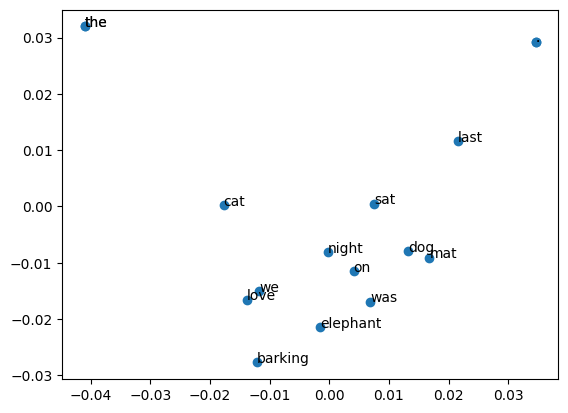

In [ ]:
plt.scatter(token_vectors_2d[:, 0], token_vectors_2d[:, 1])

for word, (x, y) in zip (tokens, token_vectors_2d):
  plt.annotate(word, (x, y))

plt.show()